# 1. Graphene

In [1]:
from pythtb import TBModel, Lattice
import numpy as np
import matplotlib.pyplot as plt

lat = [[1, 0], [1 / 2, np.sqrt(3) / 2]]
orb = [[0,0],
       [1/3,1/3]]
lattice = Lattice(lat, orb, periodic_dirs=[0, 1])

# make two dimensional tight-binding graphene model
my_model = TBModel(lattice)

# set model parameters
delta = 0
t = -2.7

# set on-site energies
my_model.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])

In [3]:
print(my_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
spinful                     = False
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000,  0.000]
  # 1 ===> [ 0.289,  0.500]

Orbital vectors (fractional):
  # 0 ===> [ 0.000,  0.000]
  # 1 ===> [ 0.000,  0.577]
----------------------------------------
Site energies:
  < 0 | H | 0 > =  0.000 
  < 1 | H | 1 > =  0.000 
Hoppings:
  < 0 | H | 1  + [ 0.0 ,  0.0 ] > = -2.7000+0.0000j
  < 1 | H | 0  + [ 1.0 , 

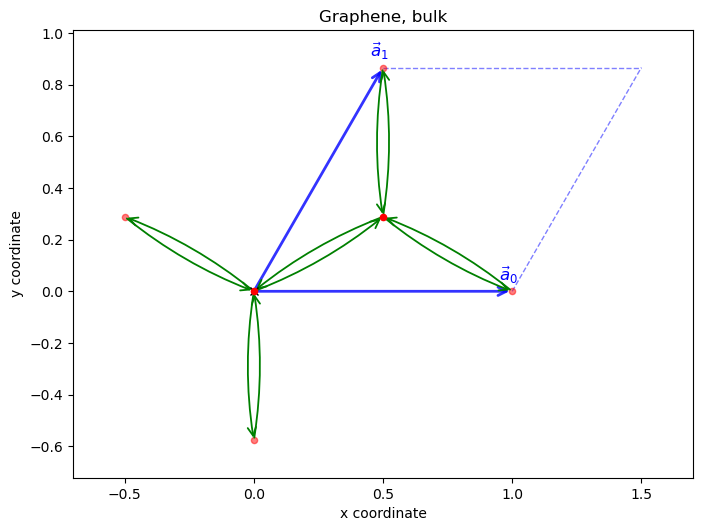

In [6]:
fig, ax = my_model.visualize()
ax.set_title("Graphene, bulk")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
plt.show()

## 1.2 Energy bands of graphene

In [2]:
# Generate k-points
nkx, nky = 31, 31
k_pts = my_model.k_uniform_mesh([nkx, nky])
H_k = my_model.hamiltonian(k_pts)
energy_bands = my_model.solve_ham(k_pts)

print("Hamiltonian shape:", H_k.shape)
print("Hamiltonian at first k-point:\n", H_k[0])
print("Hamiltonian at second k-point:\n", H_k[1])

Hamiltonian shape: (961, 2, 2)
Hamiltonian at first k-point:
 [[ 0. +0.j -8.1+0.j]
 [-8.1+0.j  0. +0.j]]
Hamiltonian at second k-point:
 [[ 0.        +0.j         -8.06056966-0.00091759j]
 [-8.06056966+0.00091759j  0.        +0.j        ]]


In [3]:
import plotly.graph_objects as go

fig3d = go.Figure(data=[
    go.Scatter3d(
        x=k_pts[:, 0],
        y=k_pts[:, 1],
        z=energy_bands[:, i],
        mode='markers',
        marker=dict(size=3),
        name=f'Band {i+1}'
    )
    for i in range(energy_bands.shape[1])
])

fig3d.update_layout(
    # title="Graphene Energy Bands",
    scene=dict(
        xaxis_title="kx",
        yaxis_title="ky",
        zaxis_title="Energy"
    )
)

fig3d.show()

## 1.3 Compare with DFT

In [4]:
k_nodes = [[0, 0], [2 / 3, 1 / 3], [1 / 2, 1 / 2], [0, 0]]
k_node_labels = (r"$\Gamma $", r"$K$", r"$M$", r"$\Gamma $")
nk = 121

k_path, k_dist, k_node_dist = my_model.k_path(k_nodes, nk)
evals = my_model.solve_ham(k_path)

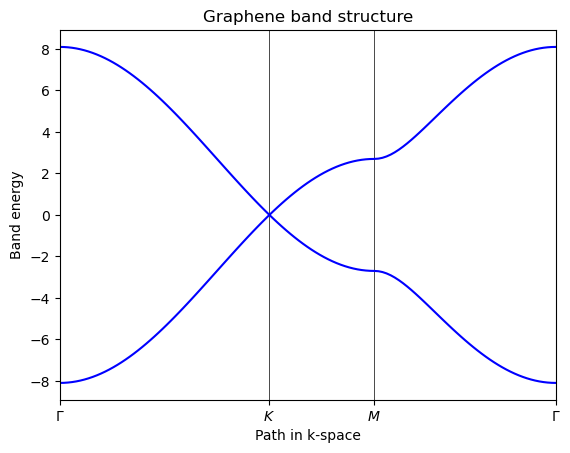

In [5]:
fig, ax = plt.subplots(dpi=100)

ax.set_xlim(k_node_dist[0], k_node_dist[-1])
ax.set_xticks(k_node_dist)
ax.set_xticklabels(k_node_labels)

for n in range(len(k_node_dist)):
    ax.axvline(x=k_node_dist[n], linewidth=0.5, color="k")

ax.set_title("Graphene band structure")
ax.set_xlabel("Path in k-space")
ax.set_ylabel("Band energy")

# plot bands
ax.plot(k_dist, evals, c="b")
plt.show()

## 1.4 Linear dispersion near the $K$ point

Zooming in on the band structure around $K$: the tight-binding bands are linear, $E(\mathbf q) = \pm \hbar v_F |\mathbf q|$, with slope $\hbar v_F = \frac{\sqrt{3}}{2}\,|t|\,a$ (here $a=1$). This is the low-energy Dirac Hamiltonian $H = \hbar v_F\, \boldsymbol{\sigma}\cdot\mathbf{q}$.

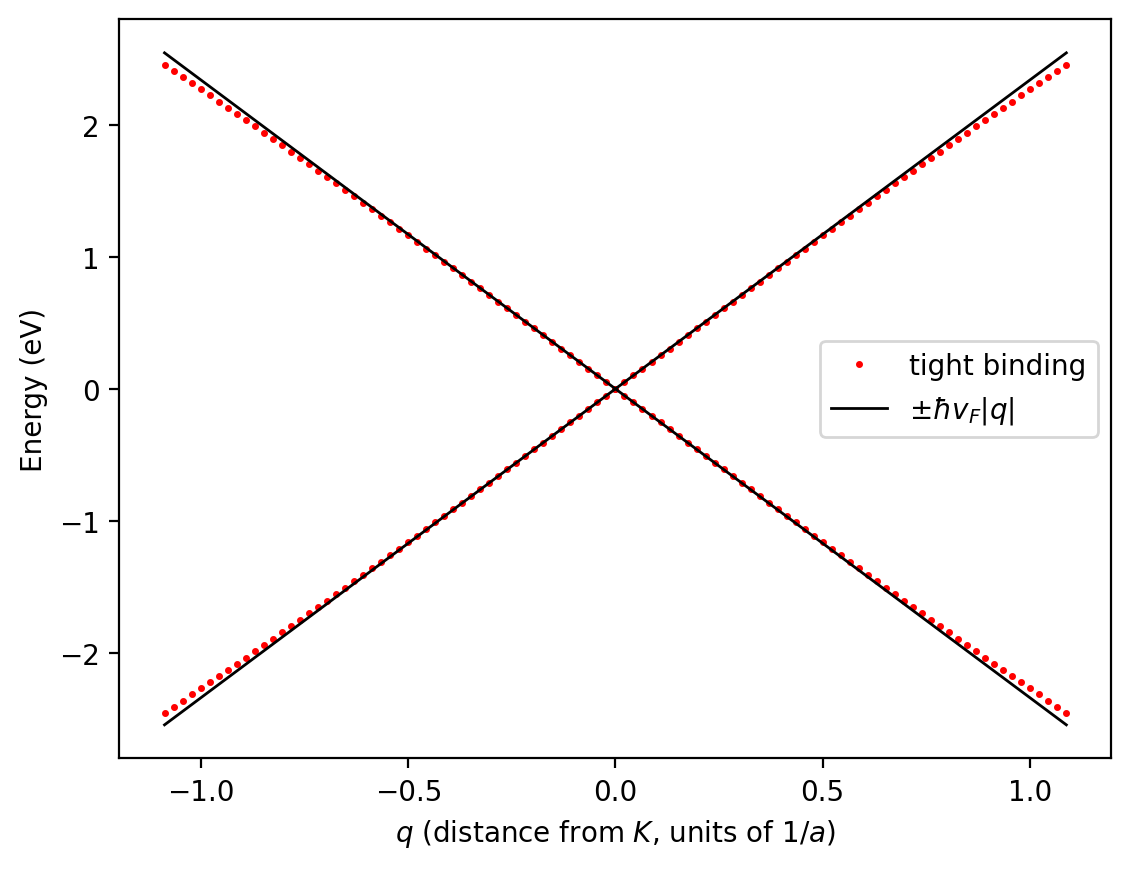

v_F = 8.74e+05 m/s  (~ c/343)


In [29]:
# cut through the K point: linear dispersion (massless Dirac fermions)
K = np.array([2 / 3, 1 / 3])
d = np.array([1.0, 0.0])  # direction of the cut (reduced coordinates)

k_zoom, k_zoom_dist, k_zoom_node = my_model.k_path([K - 0.15 * d, K, K + 0.15 * d], 101)
evals_zoom = my_model.solve_ham(k_zoom)

q = k_zoom_dist - k_zoom_node[1]    # Cartesian distance from K
hbar_vF = np.sqrt(3) / 2 * abs(t)   # slope of the cone in model units (a = 1)

fig, ax = plt.subplots(dpi=200)
ax.plot(q, evals_zoom[:, 0], "r.", ms=3, label="tight binding")
ax.plot(q, evals_zoom[:, 1], "r.", ms=3)
ax.plot(q, hbar_vF * np.abs(q), "k-", lw=1, label=r"$\pm \hbar v_F |q|$")
ax.plot(q, -hbar_vF * np.abs(q), "k-", lw=1)
ax.set_xlabel(r"$q$ (distance from $K$, units of $1/a$)")
ax.set_ylabel("Energy (eV)")
ax.legend()
plt.show()

# Fermi velocity in physical units (graphene lattice constant a = 2.46 Angstrom)
a_phys, hbar = 2.46e-10, 6.582e-16  # m, eV s
v_F = hbar_vF * a_phys / hbar
print(f"v_F = {v_F:.2e} m/s  (~ c/{3e8 / v_F:.0f})")

# 2. Zigzag graphene nanoribbon

Cutting the bulk model along $\mathbf a_2$ while keeping $\mathbf a_1$ periodic gives a ribbon with **zigzag edges**: the bottom edge terminates on sublattice $A$, the top edge on sublattice $B$. The model is periodic in one direction, so bands are functions of a single $k$.

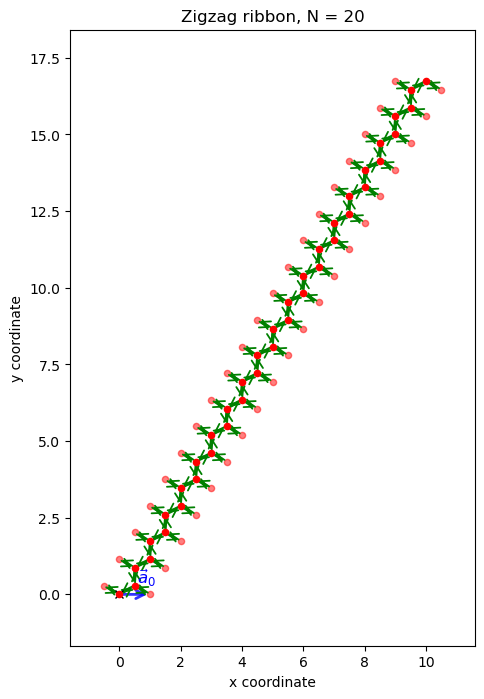

In [6]:
N = 20  # ribbon width: number of unit cells across
ribbon = my_model.cut_piece(N, 1, glue_edges=False)

fig, ax = ribbon.visualize()
ax.set_title(f"Zigzag ribbon, N = {N}")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
plt.show()

### Ribbon band structure

The hallmark of the zigzag edge: a **flat band at $E = 0$** connecting the projections of the two Dirac points, $2\pi/3 \le ka \le 4\pi/3$. These are edge states (two of them, one per edge; highlighted in color). Note that $K$ and $K'$ project onto *different* points $ka = 2\pi/3,\, 4\pi/3$ of the ribbon Brillouin zone.

evals: (201, 40)  evecs: (201, 40, 40)


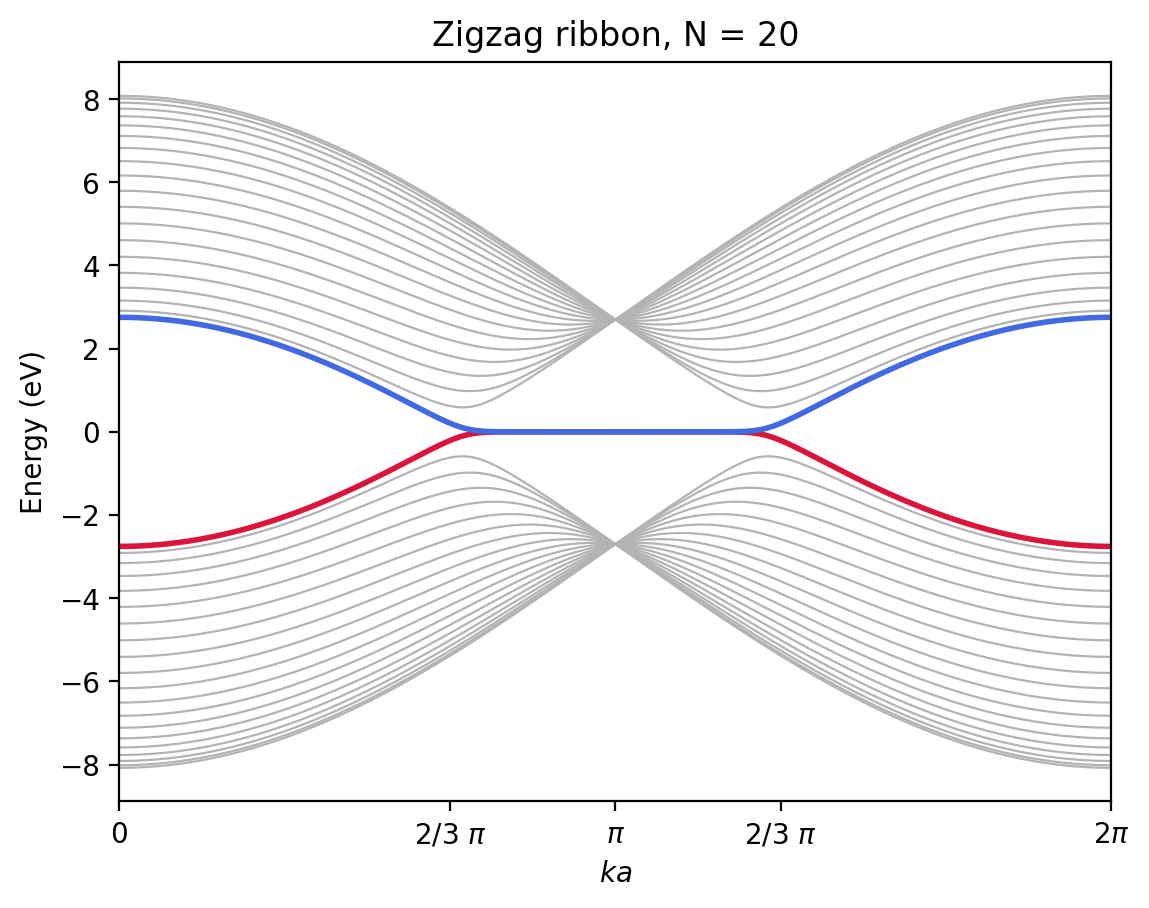

In [7]:
k_vec, k_dist, k_node_dist = ribbon.k_path([[0.0], [1/3], [0.5], [2/3], [1.0]], 201)
evals, evecs = ribbon.solve_ham(k_vec, return_eigvecs=True)
print("evals:", evals.shape, " evecs:", evecs.shape)  # (nk, 2N), (nk, 2N, 2N)

fig, ax = plt.subplots(dpi=200)
ax.plot(k_dist, evals, c="0.7", lw=0.8)
ax.plot(k_dist, evals[:, N - 1], c="crimson", lw=2)   # highest valence band
ax.plot(k_dist, evals[:, N], c="royalblue", lw=2)     # lowest conduction band
ax.set_xticks(k_node_dist)
ax.set_xticklabels([r"$0$", r"2/3 $\pi$", r"$\pi$", r"2/3 $\pi$", r"$2\pi$"])
ax.set_xlim(k_node_dist[0], k_node_dist[-1])
ax.set_xlabel(r"$ka$")
ax.set_ylabel("Energy (eV)")
ax.set_title(f"Zigzag ribbon, N = {N}")
plt.show()

To confirm that the flat band lives on the edges, color every state by its weight on the outermost sites:

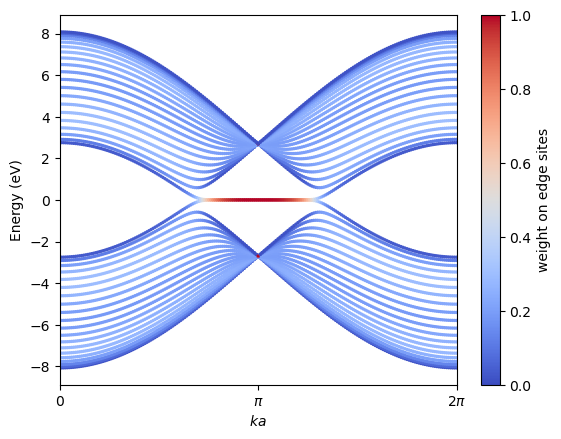

In [13]:
orb_cart = ribbon.get_orb_vecs(cartesian=True)
y = orb_cart[:, 1]
W = y.max() - y.min()
edge_sites = (y < y.min() + 0.1 * W) | (y > y.max() - 0.1 * W)

# weight of each eigenstate on the edge sites, for every k and band
edge_weight = (np.abs(evecs) ** 2)[..., edge_sites].sum(axis=-1)

fig, ax = plt.subplots()
for n in range(evals.shape[1]):
    sc = ax.scatter(k_dist, evals[:, n], c=edge_weight[:, n],
                    s=2, cmap="coolwarm", vmin=0, vmax=1)
fig.colorbar(sc, ax=ax, label="weight on edge sites")
ax.set_xticks(k_node_dist)
ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
ax.set_xlim(k_node_dist[0], k_node_dist[-1])
ax.set_xlabel(r"$ka$")
ax.set_ylabel("Energy (eV)")
plt.show()

### Edge-state localization

Analytically, the zero-energy edge state at momentum $k$ decays into the bulk as
$$|\psi_n|^2 \propto \left| 2\cos(ka/2) \right|^{2n},$$
where $n$ counts rows from the edge. It is normalizable only for $2\pi/3 < ka < 4\pi/3$ (exactly the flat-band window) and becomes perfectly localized on the outermost row at $ka = \pi$. The numerics reproduce this decay exactly:

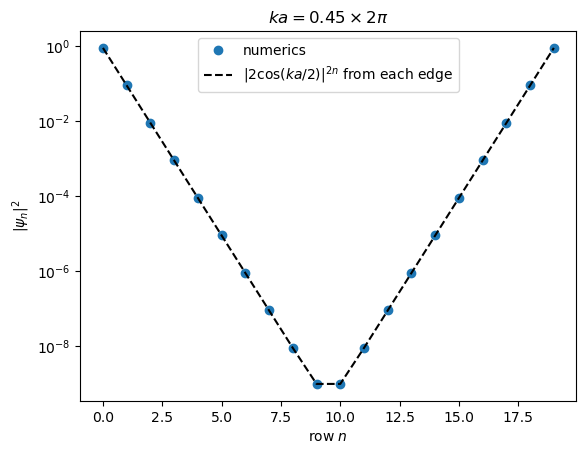

In [41]:
ik = 90                       # k-point index: ka = 0.40 * 2 pi, inside the flat-band window
ka = 2 * np.pi * k_vec[ik, 0]

# the two (nearly) degenerate midgap states, summed
prob = np.abs(evecs[ik, N - 1]) ** 2 + np.abs(evecs[ik, N]) ** 2
row_prob = prob.reshape(N, 2).sum(axis=1)   # total weight per row of the ribbon

n_row = np.arange(N)
z2 = (2 * np.cos(ka / 2)) ** 2              # analytic decay factor per row

fig, ax = plt.subplots()
ax.semilogy(n_row, row_prob, "o", label="numerics")
ax.semilogy(n_row, row_prob[0] * (z2 ** n_row + z2 ** (N - 1 - n_row)),
            "k--", label=r"$|2\cos(ka/2)|^{2n}$ from each edge")
ax.set_xlabel("row $n$")
ax.set_ylabel(r"$|\psi_n|^2$")
ax.set_title(rf"$ka = {k_vec[ik, 0]:.2f} \times 2\pi$")
ax.legend()
plt.show()

### Edge states in real space

Probability density of the two midgap states (summed), tiled along the ribbon. Each edge state is **sublattice polarized**: the state on the bottom edge lives entirely on sublattice $A$, the one on the top edge on sublattice $B$.

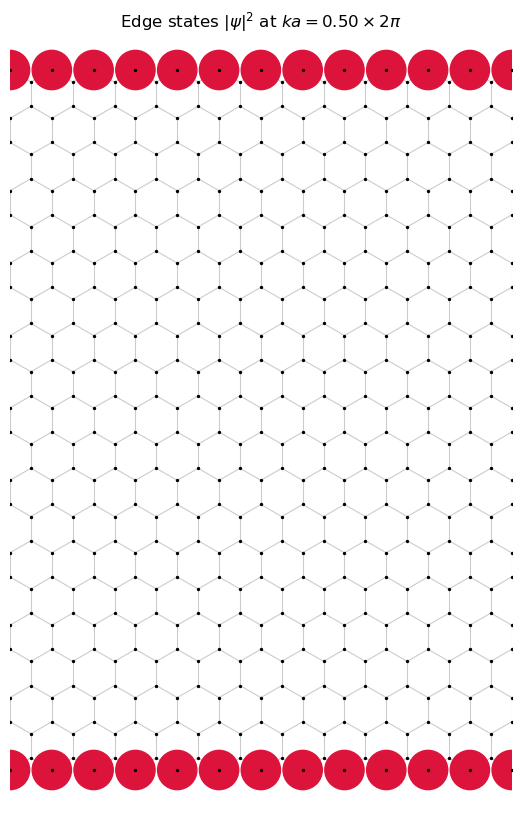

In [24]:
def plot_ribbon_state(ribbon, prob, xwin=(0, 12), scale=800):
    """Plot a probability density on the ribbon, tiled along the periodic direction."""
    pos = ribbon.get_orb_vecs(cartesian=True)
    a1 = np.array(ribbon.lattice.lat_vecs[0])
    reps = range(-15, 16)
    pts = np.vstack([pos + n * a1 for n in reps])
    w = np.tile(prob, len(reps))
    keep = (pts[:, 0] > xwin[0] - 0.4) & (pts[:, 0] < xwin[1] + 0.4)
    pts, w = pts[keep], w[keep]

    fig, ax = plt.subplots(figsize=(6, 8))
    # draw nearest-neighbor bonds (nn distance = a / sqrt(3) ~ 0.577)
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    ii, jj = np.where((dists > 0.01) & (dists < 0.62))
    for i, j in zip(ii, jj):
        if i < j:
            ax.plot(pts[[i, j], 0], pts[[i, j], 1], "-", c="0.8", lw=0.8, zorder=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=scale * w, c="crimson", zorder=2)
    ax.scatter(pts[:, 0], pts[:, 1], s=2, c="k", zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(xwin)
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

ik = 100      # k-point index
ka = 2 * np.pi * k_vec[ik, 0]

prob_pair = np.abs(evecs[ik, N - 1]) ** 2 + np.abs(evecs[ik, N]) ** 2
fig, ax = plot_ribbon_state(ribbon, prob_pair)
ax.set_title(rf"Edge states $|\psi|^2$ at $ka = {k_vec[ik, 0]:.2f} \times 2\pi$")
plt.show()